# Phase2 DL

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Convert the data into YOLO language

In [ ]:
import os
import glob
from google.colab import drive

drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/test2"

def convert_to_yolo(path):
    csv_files = glob.glob(os.path.join(path, '*.csv'))
    for csv_file in csv_files:
        txt_file = csv_file.replace('.csv', '.txt')
        with open(csv_file, 'r') as f_in, open(txt_file, 'w') as f_out:
            for line in f_in:
                parts = line.strip().split(';')
                if len(parts) != 5: continue
                l, t, r, b, label = map(float, parts)
                x_center = (l + r) / 2.0
                y_center = (t + b) / 2.0
                width = r - l
                height = b - t
                class_id = int(label) - 1
                f_out.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
    print(f"✅ تم تحويل {len(csv_files)} ملف بنجاح!")

convert_to_yolo(DATASET_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ تم تحويل 50 ملف بنجاح!


In [ ]:
yaml_content = f"""
train: {DATASET_PATH}
val: {DATASET_PATH}

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""

with open('braille_data.yaml', 'w') as f:
    f.write(yaml_content)
print("✅ تم إنشاء ملف braille_data.yaml بنجاح!")

✅ تم إنشاء ملف braille_data.yaml بنجاح!


# Big Training

In [ ]:
import os
import glob

# مسار الفولدر الجديد
DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"

def convert_all_to_yolo(path):
    print("⏳ جاري البحث عن ملفات CSV في كل الكتب...")
    # النجمة المضاعفة ** معناها إنه هيدخل جوه كل الفولدرات الفرعية
    csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

    for csv_file in csv_files:
        txt_file = csv_file.replace('.csv', '.txt')
        with open(csv_file, 'r', encoding='utf-8') as f_in, open(txt_file, 'w', encoding='utf-8') as f_out:
            for line in f_in:
                parts = line.strip().split(';')
                if len(parts) != 5: continue
                l, t, r, b, label = map(float, parts)

                # حسابات YOLO
                x_center = (l + r) / 2.0
                y_center = (t + b) / 2.0
                width = r - l
                height = b - t
                class_id = int(label) - 1 # YOLO بيبدأ من 0

                f_out.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    print(f"✅ تمت العملية! تم تحويل {len(csv_files)} صفحة كتاب بنجاح!")

convert_all_to_yolo(DATASET_PATH)

⏳ جاري البحث عن ملفات CSV في كل الكتب...
✅ تمت العملية! تم تحويل 212 صفحة كتاب بنجاح!


In [ ]:
yaml_content = f"""
# هنخلي YOLO يقرا مسارات الصور من ملفات الـ txt مباشرة
train: {DATASET_PATH}/train.txt
val: {DATASET_PATH}/val.txt

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""

with open('books_braille_data.yaml', 'w') as f:
    f.write(yaml_content)
print("✅ تم إنشاء ملف books_braille_data.yaml بنجاح!")

✅ تم إنشاء ملف books_braille_data.yaml بنجاح!


# Path Normalization & Cross-Platform Compatibility

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"

for txt_name in ['train.txt', 'val.txt']:
    file_path = os.path.join(DATASET_PATH, txt_name)

    if not os.path.exists(file_path):
        print(f"⚠️ ملف {txt_name} مش موجود في المسار ده.")
        continue

    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    cleaned_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue

        line = line.replace('\\', '/')

        if not line.startswith('/'):
            line = os.path.join(DATASET_PATH, line)

        cleaned_lines.append(line + '\n')

    with open(file_path, 'w', encoding='utf-8') as f:
        f.writelines(cleaned_lines)

    print(f"✅ تم تنظيف وتصليح مسارات الويندوز في ملف {txt_name} بنجاح!")

✅ تم تنظيف وتصليح مسارات الويندوز في ملف train.txt بنجاح!
✅ تم تنظيف وتصليح مسارات الويندوز في ملف val.txt بنجاح!


# Baseline YOLO Model (Initial Experiment)

In [ ]:
from ultralytics import YOLO

# هنستخدم نفس الموديل الخفيف والسريع
model = YOLO('yolov8n.pt')

# هنبدأ التدريب على الداتا الضخمة
model.train(
    data='books_braille_data.yaml',
    epochs=50,
    imgsz=640,
    project='/content/drive/MyDrive/ML Project/YOLO_Runs',
    name='braille_books_v1' # اسم النسخة دي من التدريب
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=books_braille_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=braille_books_v13, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 32, 33, 35, 36, 37, 39, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 57, 59, 61])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aed13e49400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034, 

I noticed that the "640" resolution is not enough, and 50 epoch is not enough not enough to reach convergence, so we will move to 1024

# Small Test


image 1/1 /content/drive/MyDrive/ML Project/AngelinaDataset/books/chudo_derevo_redmi/IMG_20190715_113013.labeled.jpg: 640x480 7 1s, 1 17, 50 21s, 2 29s, 35 30s, 13.7ms
Speed: 3.5ms preprocess, 13.7ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 480)


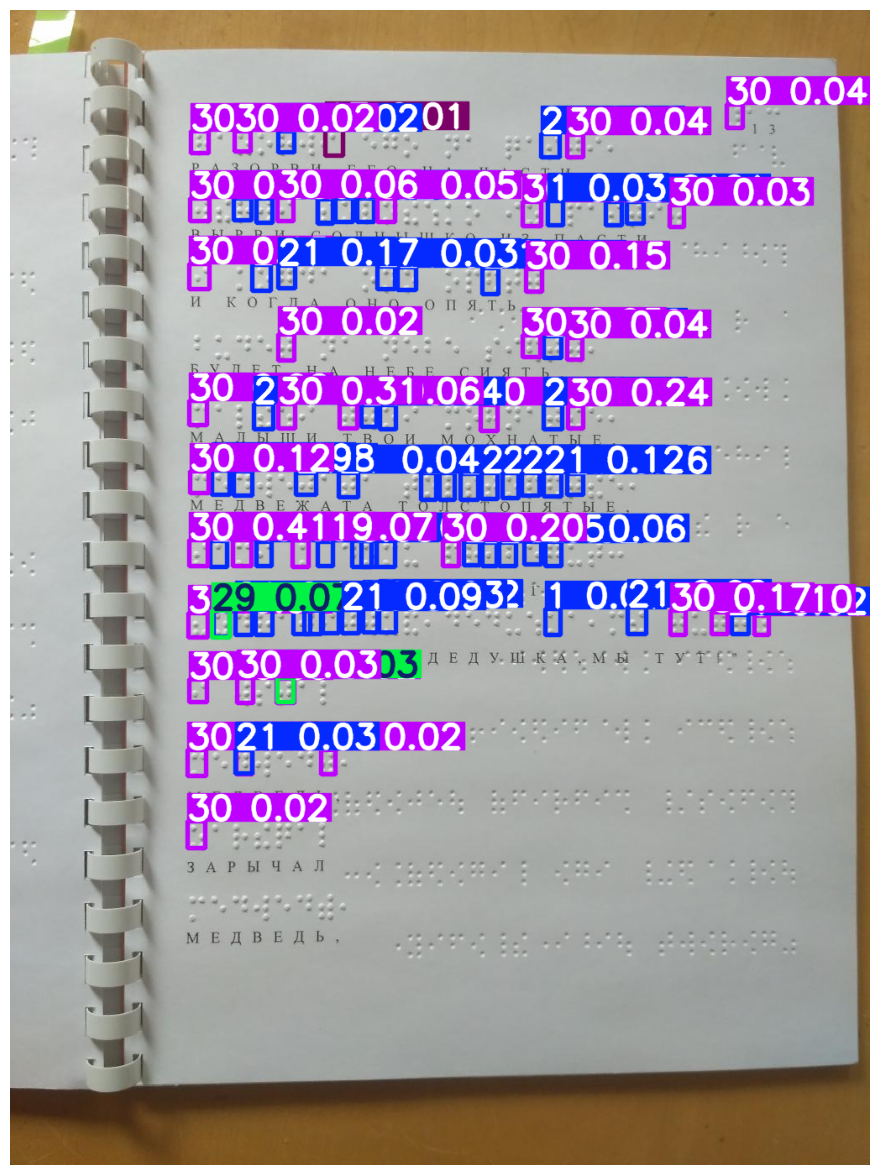

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. هنحمل أحسن أوزان (عقل الموديل) اللي لسه متدربة من ثواني
model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_books_v13/weights/best.pt'
model = YOLO(model_path)

# 2. اختار أي صورة من الداتا عشان نختبر عليها (عدل المسار لو حبيت صورة تانية)
# دي أول صورة من الفولدر اللي الموديل امتحن عليه
test_image_path = '/content/drive/MyDrive/ML Project/AngelinaDataset/books/chudo_derevo_redmi/IMG_20190715_113013.labeled.jpg'

# 3. إطلاق الوحش (التوقع) - بنقوله متطبعش نتايج ثقتها أقل من 10%
results = model.predict(source=test_image_path, conf=0.01)

# 4. رسم النتيجة وعرضها
res_plotted = results[0].plot()

# عرض الصورة
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Final Train

In [ ]:
from ultralytics import YOLO

# هنبدأ بموديل جديد نضيف عشان ندربه صح من الأول
model = YOLO('yolov8n.pt')

# إعدادات الوحش
model.train(
    data='books_braille_data.yaml',
    epochs=150,           # زودنا اللفات عشان يبني ثقة
    imgsz=1024,           # كبرنا الصورة عشان النقط توضح
    batch=8,              # قللنا الباتش شوية عشان ميموري الـ GPU تستحمل الـ 1024
    patience=30,          # لو الموديل متحسنش لمدة 30 لفة، هيوقف لوحده توفيراً للوقت
    project='/content/drive/MyDrive/ML Project/YOLO_Runs',
    name='braille_books_v2_HighRes'
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=books_braille_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=braille_books_v2_HighRes, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

# Wave 2

In [ ]:
# 1. ربط الدرايف وتثبيت المكتبة
from google.colab import drive
drive.mount('/content/drive')
!pip install ultralytics -q

# 2. إعادة إنشاء ملف الـ YAML اللي كولاب مسحه
import os
DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
yaml_content = f"""
train: {DATASET_PATH}/train.txt
val: {DATASET_PATH}/val.txt

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
with open('books_braille_data.yaml', 'w') as f:
    f.write(yaml_content)
print("✅ تم ربط الدرايف وإعادة إنشاء ملف books_braille_data.yaml بنجاح!")

# 3. استكمال التدريب
from ultralytics import YOLO

# مسار آخر أوزان وقفنا عندها
model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_books_v2_HighRes/weights/last.pt'
model = YOLO(model_path)

# استكمال التدريب بباتش 4 عشان نريح الـ GPU
print("⏳ جاري استكمال التدريب...")
model.train(resume=True, batch=4)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ تم ربط الدرايف وإعادة إنشاء ملف books_braille_data.yaml بنجاح!
⏳ جاري استكمال التدريب...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=books_braille_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 32, 33, 35, 36, 37, 39, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 57, 59, 61])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aabfec98c20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034, 

# Wave 3

In [ ]:
# 0. تثبيت مكتبة YOLO عشان كولاب بيرجع زيرو كل مرة يقفل
!pip install ultralytics -q

import os
import glob
import random
from ultralytics import YOLO

DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"

print("🔍 جاري البحث عن كل الصور في جميع الكتب...")
# 1. حصاد كل الصور من كل الفولدرات
all_images = glob.glob(os.path.join(DATASET_PATH, '**', '*.jpg'), recursive=True)

valid_images = []
for img_path in all_images:
    # التأكد إن الصورة ليها ملف إحداثيات txt
    txt_path = img_path.replace('.jpg', '.txt')
    if os.path.exists(txt_path):
        # توحيد شكل المسارات لـ Linux لتجنب أي أخطاء
        valid_images.append(img_path.replace('\\', '/'))

print(f"✅ تم العثور على {len(valid_images)} صفحة برايل جاهزة للتدريب!")

# 2. خلط الصور عشوائياً عشان الموديل يشوف كل الكتب مع بعض
random.seed(42)
random.shuffle(valid_images)

# 3. تقسيم الداتا: 85% تدريب و 15% امتحان
split_idx = int(len(valid_images) * 0.85)
train_images = valid_images[:split_idx]
val_images = valid_images[split_idx:]

# 4. إنشاء ملفات الـ txt الجديدة الشاملة
train_txt_path = os.path.join(DATASET_PATH, 'train_all.txt')
val_txt_path = os.path.join(DATASET_PATH, 'val_all.txt')

with open(train_txt_path, 'w', encoding='utf-8') as f:
    f.writelines([img + '\n' for img in train_images])

with open(val_txt_path, 'w', encoding='utf-8') as f:
    f.writelines([img + '\n' for img in val_images])

print(f"✅ تم تجهيز الداتا: {len(train_images)} للتدريب، و {len(val_images)} للامتحان.")

# 5. إنشاء ملف الـ YAML الجديد
yaml_content = f"""
train: {train_txt_path}
val: {val_txt_path}

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
yaml_path = '/content/books_all_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print("✅ تم إنشاء ملف books_all_data.yaml بنجاح!")

# 6. بدء التدريب النهائي للـ Product
print("🚀 إطلاق التدريب الشامل النهائي...")
# هنبدأ من موديل جديد نضيف عشان يتعلم على الداتا الضخمة كلها من الصفر
model = YOLO('yolov8n.pt')

model.train(
    data=yaml_path,
    epochs=100,           # 100 لفة كافية جداً مع حجم الداتا الكبير ده
    imgsz=1024,           # ريزوليوشن عالي لضمان رؤية النقط
    batch=4,              # باتش صغير عشان الميموري ماتضربش
    patience=25,          # لو الدقة وقفت هيخلص بدري
    project='/content/drive/MyDrive/ML Project/YOLO_Runs',
    name='braille_Product_Final'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔍 جاري البحث عن كل الصور في جميع الكتب...
✅ تم العثور على 212 صفحة برايل جاهزة للتدريب!
✅ تم تجهيز الداتا: 180 للتدريب، و 32 للامتحان.
✅ تم إنشاء ملف books_all_data.yaml بنجاح!
🚀 إطلاق التدريب الشامل النهائي...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/books_all_data

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 12, 13, 14, 16, 17, 18, 20, 21, 22, 24, 25, 26, 28, 29, 30, 32, 33, 35, 36, 37, 39, 41, 42, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 57, 59, 61])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x787ee57e68a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0

# Augmented code to fix the low percentage of some letters

In [ ]:
# 0. تثبيت مكتبة YOLO
!pip install ultralytics -q

import os
from ultralytics import YOLO

# 1. إعادة إنشاء ملف الـ YAML اللي كولاب مسحه
DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
train_txt_path = f"{DATASET_PATH}/train_all.txt"
val_txt_path = f"{DATASET_PATH}/val_all.txt"

yaml_content = f"""
train: {train_txt_path}
val: {val_txt_path}

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
yaml_path = '/content/books_all_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print("✅ تم إعادة إنشاء ملف books_all_data.yaml بنجاح!")

# 2. تحميل الموديل النهائي عشان ياخد الجرعة العلاجية
model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Final/weights/best.pt'
model = YOLO(model_path)

print("💉 جاري بدء الجرعة العلاجية للحروف النادرة...")

# 3. إعدادات التدريب الهجومية (Heavy Augmentation)
model.train(
    data=yaml_path,
    epochs=50,                  # 50 لفة بس كفاية كعلاج
    imgsz=1024,
    batch=4,
    project='/content/drive/MyDrive/ML Project/YOLO_Runs',
    name='braille_Product_Augmented',

    # --- أسلحة تكثير البيانات (Augmentation Magic) ---
    mosaic=1.0,                 # دمج 4 صور في صورة واحدة
    mixup=0.2,                  # دمج صورتين فوق بعض بشفافية
    copy_paste=0.3,             # نسخ ولزق الحروف النادرة
    degrees=5.0,                # ميلان خفيف للصور
    shear=2.0,                  # شد الصورة

    # --- إجبار الموديل يركز على الأخطاء ---
    cls=2.0                     # مضاعفة العقاب لو اتلخبط في تصنيف حرف
)

✅ تم إعادة إنشاء ملف books_all_data.yaml بنجاح!
💉 جاري بدء الجرعة العلاجية للحروف النادرة...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/books_all_data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Final/weight

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 12, 13, 14, 16, 17, 18, 20, 21, 22, 24, 25, 26, 28, 29, 30, 32, 33, 35, 36, 37, 39, 41, 42, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 57, 59, 61])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a918423ce00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0

# OCR Pipeline

# The Braille Unicode Magic

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Augmented2/weights/best.pt'
model = YOLO(model_path)

test_image_path = '/content/drive/MyDrive/ML Project/AngelinaDataset/test2/0c62b07dc3ff44e4982cbb573f3b6d95.labeled.jpg'

print("⏳ جاري تحليل الصورة واستخراج البرايل الأصلي...")
results = model.predict(source=test_image_path, conf=0.15, imgsz=1024)

boxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

detected_items = []
for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    class_id = int(classes[i])
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2
    detected_items.append({'x': x_center, 'y': y_center, 'class': class_id})

detected_items.sort(key=lambda item: item['y'])

lines = []
current_line = []
line_threshold = 45

if detected_items:
    current_line.append(detected_items[0])
    for item in detected_items[1:]:
        if abs(item['y'] - current_line[-1]['y']) < line_threshold:
            current_line.append(item)
        else:
            current_line.sort(key=lambda x: x['x'])
            lines.append(current_line)
            current_line = [item]
    current_line.sort(key=lambda x: x['x'])
    lines.append(current_line)

print("\n" + "=" * 50)
print(" النص المستخرج (بصيغة برايل القياسية):")
print("=" * 50)

for line in lines:
    line_text = ""
    for char in line:
        class_id = char['class']
        braille_char = chr(0x2800 + class_id + 1)
        line_text += braille_char + " "
    print(line_text)
print("=" * 50 + "\n")

⏳ جاري تحليل الصورة واستخراج البرايل الأصلي...

image 1/1 /content/drive/MyDrive/ML Project/AngelinaDataset/test2/0c62b07dc3ff44e4982cbb573f3b6d95.labeled.jpg: 768x1024 18 1s, 5 2s, 11 3s, 7 5s, 14 7s, 9 10s, 9 17s, 1 21, 10 25s, 1 26, 1 30, 2 47s, 1 53, 1 58, 13.9ms
Speed: 4.1ms preprocess, 13.9ms inference, 2.4ms postprocess per image at shape (1, 3, 768, 1024)

📝 النص المستخرج (بصيغة برايل القياسية):
⠙ ⠇ ⠇ ⠙ ⠁ ⠃ ⠃ ⠇ ⠇ ⠃ ⠁ ⠇ ⠇ ⠃ ⠑ ⠑ ⠊ ⠊ ⠇ ⠇ ⠙ ⠑ ⠊ ⠇ ⠙ ⠃ ⠑ ⠂ ⠊ ⠑ ⠊ ⠵ ⠯ ⠇ ⠑ ⠊ 
⠃ ⠃ ⠇ ⠃ ⠅ ⠇ ⠁ ⠁ ⠺ ⠞ ⠅ ⠁ ⠚ ⠊ 
⠂ ⠇ ⠁ ⠃ ⠁ ⠁ ⠅ ⠅ ⠁ ⠅ ⠁ ⠁ ⠁ ⠑ ⠙ ⠃ ⠙ ⠃ ⠁ ⠇ ⠁ ⠅ ⠙ ⠕ ⠙ ⠅ ⠑ ⠊ ⠁ ⠁ ⠂ ⠙ ⠯ ⠑ ⠊ ⠂ ⠁ ⠙ ⠂ 
⠁ 



# Human Translation

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# 1. القاموس السحري: تحويل أرقام الكلاسات (المبنية على نظام البايتات) لحروف إنجليزي
# المعادلة: رقم الكلاس = (مجموع أوزان النقط) - 1
braille_to_english = {
    0: 'a', 2: 'b', 8: 'c', 24: 'd', 16: 'e', 10: 'f', 26: 'g', 18: 'h', 9: 'i', 25: 'j',
    4: 'k', 6: 'l', 12: 'm', 28: 'n', 20: 'o', 14: 'p', 30: 'q', 22: 'r', 13: 's', 29: 't',
    36: 'u', 38: 'v', 57: 'w', 44: 'x', 60: 'y', 52: 'z'
}

# 2. تحميل الموديل المعالج
model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Augmented2/weights/best.pt'
model = YOLO(model_path)

# 3. صورة الاختبار
test_image_path = '/content/drive/MyDrive/ML Project/AngelinaDataset/test2/0c62b07dc3ff44e4982cbb573f3b6d95.labeled.jpg'

print("⏳ جاري قراءة الصورة والترجمة للغة البشر...")
results = model.predict(source=test_image_path, conf=0.15, imgsz=1024)

boxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

detected_items = []
for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    class_id = int(classes[i])
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2
    detected_items.append({'x': x_center, 'y': y_center, 'class': class_id})

# --- خوارزمية الترتيب ---
detected_items.sort(key=lambda item: item['y'])

lines = []
current_line = []
line_threshold = 45

if detected_items:
    current_line.append(detected_items[0])
    for item in detected_items[1:]:
        if abs(item['y'] - current_line[-1]['y']) < line_threshold:
            current_line.append(item)
        else:
            current_line.sort(key=lambda x: x['x'])
            lines.append(current_line)
            current_line = [item]
    current_line.sort(key=lambda x: x['x'])
    lines.append(current_line)

print("\n" + "=" * 50)
print("📝 النص المترجم:")
print("=" * 50)

for line in lines:
    english_line = ""
    for char in line:
        class_id = char['class']

        # لو الحرف في قاموس الحروف الإنجليزي هنجيبه
        if class_id in braille_to_english:
            english_line += braille_to_english[class_id]
        else:
            # لو الحرف مش في القاموس (علامة ترقيم أو رقم)، هنطبعه كرمز برايل عشان مانفقدوش
            braille_char = chr(0x2800 + class_id + 1)
            english_line += braille_char

    print(english_line)

print("=" * 50 + "\n")

⏳ جاري قراءة الصورة والترجمة للغة البشر...

image 1/1 /content/drive/MyDrive/ML Project/AngelinaDataset/test2/0c62b07dc3ff44e4982cbb573f3b6d95.labeled.jpg: 768x1024 18 1s, 5 2s, 11 3s, 7 5s, 14 7s, 9 10s, 9 17s, 1 21, 10 25s, 1 26, 1 30, 2 47s, 1 53, 1 58, 23.0ms
Speed: 9.6ms preprocess, 23.0ms inference, 3.9ms postprocess per image at shape (1, 3, 768, 1024)

📝 النص المترجم:
dlldabbllballbeeiilldeildbe⠂ieiz⠯lei
bblbklaawtkaji
⠂labaakkakaaaedbdbalakdodkeiaa⠂d⠯ei⠂ad⠂
a



# The Space Algorithm

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

braille_to_english = {
    0: 'a', 2: 'b', 8: 'c', 24: 'd', 16: 'e', 10: 'f', 26: 'g', 18: 'h', 9: 'i', 25: 'j',
    4: 'k', 6: 'l', 12: 'm', 28: 'n', 20: 'o', 14: 'p', 30: 'q', 22: 'r', 13: 's', 29: 't',
    36: 'u', 38: 'v', 57: 'w', 44: 'x', 60: 'y', 52: 'z'
}

model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_Product_Augmented2/weights/best.pt'
model = YOLO(model_path)

test_image_path = '/content/drive/MyDrive/ML Project/AngelinaDataset/test2/0c62b07dc3ff44e4982cbb573f3b6d95.labeled.jpg'

results = model.predict(source=test_image_path, conf=0.15, imgsz=1024)

boxes = results[0].boxes.xyxy.cpu().numpy()
classes = results[0].boxes.cls.cpu().numpy()

detected_items = []
for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    class_id = int(classes[i])
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2
    detected_items.append({'x': x_center, 'y': y_center, 'class': class_id})

# الترتيب من فوق لتحت (السطور)
detected_items.sort(key=lambda item: item['y'])

lines = []
current_line = []
line_threshold = 45

if detected_items:
    current_line.append(detected_items[0])
    for item in detected_items[1:]:
        if abs(item['y'] - current_line[-1]['y']) < line_threshold:
            current_line.append(item)
        else:
            current_line.sort(key=lambda x: x['x'])
            lines.append(current_line)
            current_line = [item]
    current_line.sort(key=lambda x: x['x'])
    lines.append(current_line)

print("\n" + "=" * 50)
print("📝 النص المترجم (مضاف إليه المسافات):")
print("=" * 50)

# المسافة التقريبية بين حرفين عشان نعتبرها Space (ممكن نعدلها حسب حجم الصورة)
space_threshold = 40

for line in lines:
    english_line = ""
    for j in range(len(line)):
        char = line[j]

        # 🌟 خوارزمية اكتشاف المسافات
        if j > 0:
            prev_char = line[j-1]
            distance = char['x'] - prev_char['x']
            if distance > space_threshold:
                english_line += " " # إضافة مسافة

        class_id = char['class']
        if class_id in braille_to_english:
            english_line += braille_to_english[class_id]
        else:
            braille_char = chr(0x2800 + class_id + 1)
            english_line += braille_char

    print(english_line)

print("=" * 50 + "\n")


image 1/1 /content/drive/MyDrive/ML Project/AngelinaDataset/test2/0c62b07dc3ff44e4982cbb573f3b6d95.labeled.jpg: 768x1024 18 1s, 5 2s, 11 3s, 7 5s, 14 7s, 9 10s, 9 17s, 1 21, 10 25s, 1 26, 1 30, 2 47s, 1 53, 1 58, 16.8ms
Speed: 9.2ms preprocess, 16.8ms inference, 3.7ms postprocess per image at shape (1, 3, 768, 1024)

📝 النص المترجم (مضاف إليه المسافات):
dlldabb llba llbeeii lldei ldbe⠂iei z⠯lei
b b l b k laawt kaji
⠂labaa kkakaaaedbdba lakdodk eiaa⠂ d ⠯ei⠂ad ⠂
a



#Below, i convert Yolo8nano to small, to get higher output quality
#- Data Augmentation
#- I made "cls=2.0" --> the model will not punished on spaces as punish as wrong classification\

In [ ]:
import os
from ultralytics import YOLO

# 1. إعادة إنشاء ملف الـ YAML اللي كولاب مسحه
DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
train_txt_path = f"{DATASET_PATH}/train_all.txt"
val_txt_path = f"{DATASET_PATH}/val_all.txt"

yaml_content = f"""
train: {train_txt_path}
val: {val_txt_path}

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
yaml_path = '/content/books_all_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print("✅ تم إعادة إنشاء ملف books_all_data.yaml بنجاح!")

# 2. تحميل موديل YOLOv8s (النسخة الأكبر والأذكى)
print("🚀 جاري تحميل موديل YOLOv8s وبدء التدريب...")
model = YOLO('yolov8s.pt')

# 3. بدء التدريب المدمج (موديل كبير + تكثير بيانات للحروف النادرة)
model.train(
    data=yaml_path,
    epochs=100,
    imgsz=1024,
    batch=4,
    project='/content/drive/MyDrive/ML Project/YOLO_Runs',
    name='braille_YOLO_Small_Final',

    # دمجنا الـ Augmentation عشان الموديل الجديد ميعانيش من نفس مشكلة الحروف النادرة
    mosaic=1.0,
    mixup=0.2,
    copy_paste=0.3,
    degrees=5.0,
    shear=2.0,
    cls=2.0
)

✅ تم إعادة إنشاء ملف books_all_data.yaml بنجاح!
🚀 جاري تحميل موديل YOLOv8s وبدء التدريب...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/books_all_data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=braille_YOL

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 12, 13, 14, 16, 17, 18, 20, 21, 22, 24, 25, 26, 28, 29, 30, 32, 33, 35, 36, 37, 39, 41, 42, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 57, 59, 61])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a70cd0abfe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0

In [ ]:
!pip install ultralytics gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.0 MB/s eta 0:00:00


In [ ]:
import os
from ultralytics import YOLO

# 1. كتابة ملف الـ yaml أوتوماتيك عشان كولاب بينساه
DATASET_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
train_txt_path = f"{DATASET_PATH}/train_all.txt"
val_txt_path = f"{DATASET_PATH}/val_all.txt"

yaml_content = f"""
train: {train_txt_path}
val: {val_txt_path}

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
yaml_path = '/content/books_all_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ تم تجهيز خريطة البيانات (books_all_data.yaml)")

# 2. تحميل أذكى أوزان وصلنا ليها
model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Final-2/weights/best.pt'
model = YOLO(model_path)

print("📊 جاري حساب دقة الموديل النهائي (mAP)...")
# 3. تقييم الموديل على داتا الاختبار
metrics = model.val(data=yaml_path, imgsz=1024)

print("\n" + "="*40)
print("🎯 الدقة الكلية (mAP@50):", round(metrics.box.map50 * 100, 2), "%")
print("="*40)

📊 جاري حساب الدقة باستخدام تقنية TTA المتقدمة...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,149,965 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 2.2±1.9 ms, read: 19.5±8.0 MB/s, size: 98.5 KB)
val: Scanning /content/drive/MyDrive/ML Project/AngelinaDataset/books/chudo_derevo_redmi.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 6.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.6s/it 7.1s
                   all         32       9139      0.866      0.656      0.672      0.527
                     1         32        705      0.967      0.817      0.814      0.625
                     2         29        241      0.929      0.805      0.798      0.578
                     3         32        176      0.917      0.847       0.85      0.646
                     5         32        416      0.

# EDA & Confusion Matrix

⏳ جاري قراءة ملفات الداتا لعمل الـ EDA...


/tmp/ipykernel_2609/2957296432.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=class_counts, palette="viridis")


✅ تم قراءة 66133 حرف من الداتا!


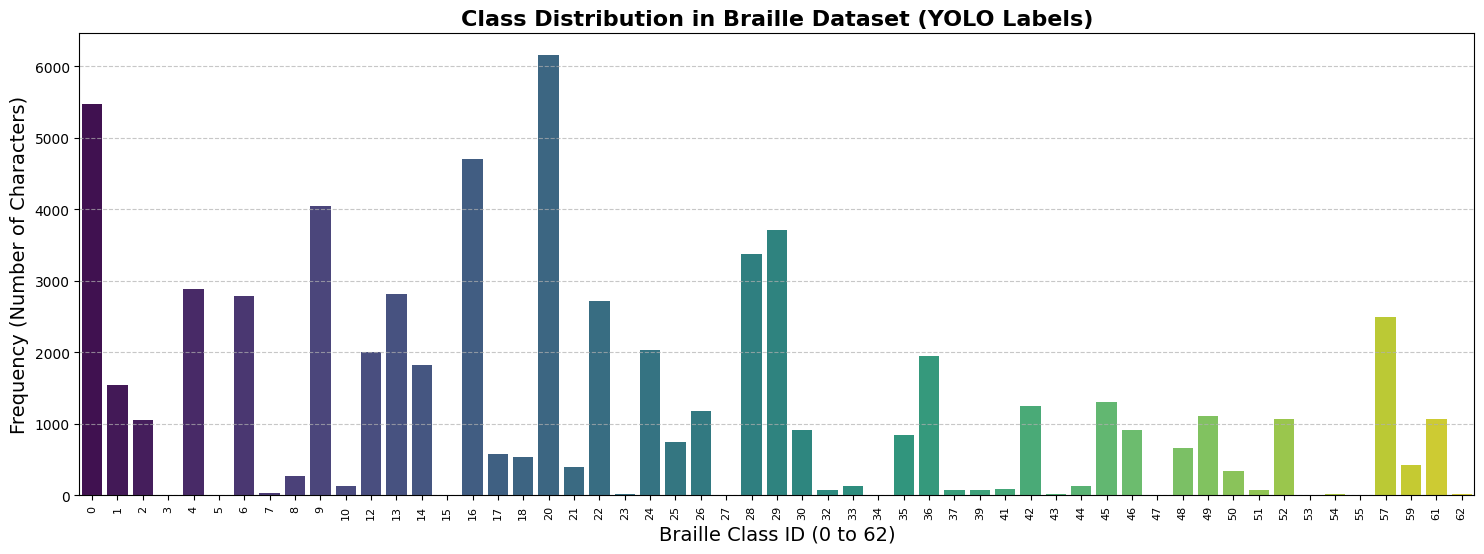


⏳ جاري رسم خريطة الترابط (Correlation Heatmap)...


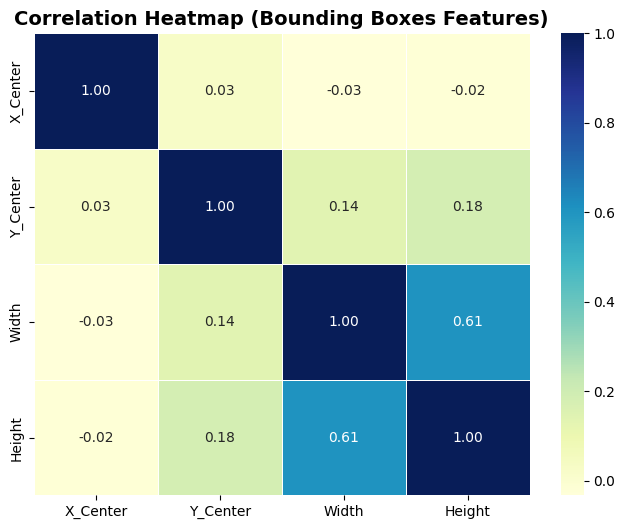

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"

class_counts = []

print("⏳ جاري قراءة ملفات الداتا لعمل الـ EDA...")

if os.path.exists(dataset_path):
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(".txt") and file not in ["train.txt", "val.txt", "train_all.txt", "val_all.txt", "classes.txt", "labels.txt"]:
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            parts = line.strip().split()
                            if len(parts) >= 5 and parts[0].isdigit():
                                class_counts.append(int(parts[0]))
                except:
                    continue

if len(class_counts) > 0:
    plt.figure(figsize=(18, 6))
    sns.countplot(x=class_counts, palette="viridis")

    plt.title("Class Distribution in Braille Dataset (YOLO Labels)", fontsize=16, fontweight='bold')
    plt.xlabel("Braille Class ID (0 to 62)", fontsize=14)
    plt.ylabel("Frequency (Number of Characters)", fontsize=14)

    plt.xticks(rotation=90, fontsize=8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    print(f"✅ تم قراءة {len(class_counts)} حرف من الداتا!")
    plt.show()
else:
    print("❌ لم يتم العثور على كلاسات. يرجى التأكد من مسار dataset_path.")


print("\n⏳ جاري رسم خريطة الترابط (Correlation Heatmap)...")

bboxes_data = []
if os.path.exists(dataset_path):
    for root, dirs, files in os.walk(dataset_path):
        for file in files[:200]:
            if file.endswith(".txt") and file not in ["train.txt", "val.txt", "train_all.txt", "val_all.txt", "classes.txt", "labels.txt"]:
                try:
                    with open(os.path.join(root, file), 'r') as f:
                        for line in f.readlines():
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                bboxes_data.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
                except:
                    continue

if len(bboxes_data) > 0:
    df_boxes = pd.DataFrame(bboxes_data, columns=['X_Center', 'Y_Center', 'Width', 'Height'])
    corr_matrix = df_boxes.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap (Bounding Boxes Features)", fontsize=14, fontweight='bold')
    plt.show()

# Synthetic Data Generation (because there are some letters has low percentage
there are many classes the training accuracy of them is 0 so i should fix it

The Data Factory

In [ ]:
import os
import cv2
import numpy as np
import random
from tqdm.notebook import tqdm

# 1. إنشاء المجلدات في الدرايف
output_dir = "/content/drive/MyDrive/ML Project/Synthetic_Braille"
os.makedirs(f"{output_dir}/images/train", exist_ok=True)
os.makedirs(f"{output_dir}/labels/train", exist_ok=True)

print("⏳ جاري توليد 500 صورة برايل صناعية (تشمل 50,000 حرف)...")

num_images = 500
img_size = 640
chars_per_row = 10
chars_per_col = 10
margin = 60
spacing_x = (img_size - 2 * margin) // chars_per_row
spacing_y = (img_size - 2 * margin) // chars_per_col

for img_idx in tqdm(range(num_images)):
    # خلفية عشوائية تحاكي الورق
    bg_color = random.randint(180, 255)
    img = np.ones((img_size, img_size, 3), dtype=np.uint8) * bg_color

    # تدرج إضاءة عشوائي (عشان الإضاءة ماتبقاش مثالية)
    grad = np.linspace(random.uniform(0.6, 1.1), random.uniform(0.6, 1.1), img_size)
    img = np.clip(img * grad[:, None, None], 0, 255).astype(np.uint8)

    labels = []

    for row in range(chars_per_col):
        for col in range(chars_per_row):
            # اختيار كلاس عشوائي من الـ 63 كلاس عشان نغطي كل النواقص بالتساوي
            class_id = random.randint(0, 62)

            dot_radius = random.randint(4, 6)
            dot_spacing = random.randint(18, 22)

            top_left_x = margin + col * spacing_x + random.randint(-8, 8)
            top_left_y = margin + row * spacing_y + random.randint(-8, 8)

            # تحويل الكلاس لنقط برايل بالعمليات الثنائية (Bitwise)
            val = class_id + 1
            dots = [
                (val & 1), (val & 2), (val & 4),
                (val & 8), (val & 16), (val & 32)
            ]

            positions = [
                (top_left_x, top_left_y),
                (top_left_x, top_left_y + dot_spacing),
                (top_left_x, top_left_y + 2 * dot_spacing),
                (top_left_x + dot_spacing, top_left_y),
                (top_left_x + dot_spacing, top_left_y + dot_spacing),
                (top_left_x + dot_spacing, top_left_y + 2 * dot_spacing),
            ]

            has_dots = False
            for i, is_active in enumerate(dots):
                if is_active:
                    has_dots = True
                    pt = (positions[i][0], positions[i][1])
                    cv2.circle(img, pt, dot_radius, (120, 120, 120), -1)          # ظل
                    cv2.circle(img, (pt[0]-1, pt[1]-1), dot_radius-1, (50, 50, 50), -1) # النقطة

            if has_dots:
                # إحداثيات YOLO
                box_w = dot_spacing + 2 * dot_radius + 6
                box_h = 2 * dot_spacing + 2 * dot_radius + 6
                box_cx = top_left_x + dot_spacing / 2
                box_cy = top_left_y + dot_spacing

                nx = np.clip(box_cx / img_size, 0, 1)
                ny = np.clip(box_cy / img_size, 0, 1)
                nw = np.clip(box_w / img_size, 0, 1)
                nh = np.clip(box_h / img_size, 0, 1)

                labels.append(f"{class_id} {nx:.6f} {ny:.6f} {nw:.6f} {nh:.6f}")

    # إضافة ضوضاء (Noise)
    noise = np.random.normal(0, random.randint(5, 20), img.shape).astype(np.float32)
    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # تمويه عشوائي (Blur)
    if random.random() > 0.4:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)

    # حفظ الصورة والـ txt
    cv2.imwrite(f"{output_dir}/images/train/synth_{img_idx}.jpg", img)
    with open(f"{output_dir}/labels/train/synth_{img_idx}.txt", "w") as f:
        f.write("\n".join(labels))

print("✅ تم الانتهاء! الداتا الصناعية جاهزة وتنتظر الدمج.")

⏳ جاري توليد 500 صورة برايل صناعية (تشمل 50,000 حرف)...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ تم الانتهاء! الداتا الصناعية جاهزة وتنتظر الدمج.


تحديث خريطة البيانات (The Merge)

In [ ]:
# مسارات الداتا
REAL_DATA_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
SYNTHETIC_DATA_PATH = "/content/drive/MyDrive/ML Project/Synthetic_Braille/images/train"

yaml_content = f"""
train:
  - {REAL_DATA_PATH}/train_all.txt
  - {SYNTHETIC_DATA_PATH}
val: {REAL_DATA_PATH}/val_all.txt

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
yaml_path = '/content/books_mixed_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ تم دمج الداتا الحقيقية والصناعية في ملف books_mixed_data.yaml")

✅ تم دمج الداتا الحقيقية والصناعية في ملف books_mixed_data.yaml


YOLOv8s Training

In [ ]:
import os
from ultralytics import YOLO

# 1. نعيد إنشاء ملف الخريطة (لأن كولاب مسحه)
REAL_DATA_PATH = "/content/drive/MyDrive/ML Project/AngelinaDataset/books"
SYNTHETIC_DATA_PATH = "/content/drive/MyDrive/ML Project/Synthetic_Braille/images/train"

yaml_content = f"""
train:
  - {REAL_DATA_PATH}/train_all.txt
  - {SYNTHETIC_DATA_PATH}
val: {REAL_DATA_PATH}/val_all.txt

nc: 63
names: [ {','.join([f"'{i+1}'" for i in range(63)])} ]
"""
yaml_path = '/content/books_mixed_data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ تم إعادة إنشاء ملف الخريطة (books_mixed_data.yaml) بنجاح!")

# 2. تحميل الأوزان اللي وقفنا عندها (من آخر لفة)
# لاحظ إننا بنشاور على الفولدر الأصلي مش الفولدر الجديد
last_weight_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Synthetic_Merged/weights/last.pt'
model = YOLO(last_weight_path)

print("🔄 جاري استكمال التدريب من اللحظة اللي كولاب فصل فيها...")

# 3. أمر الاستكمال (Resume)
model.train(resume=True)

✅ تم إعادة إنشاء ملف الخريطة (books_mixed_data.yaml) بنجاح!
🔄 جاري استكمال التدريب من اللحظة اللي كولاب فصل فيها...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/books_mixed_data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/ML Project/YOLO_Runs/br

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 12, 13, 14, 16, 17, 18, 20, 21, 22, 24, 25, 26, 28, 29, 30, 32, 33, 35, 36, 37, 39, 41, 42, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 57, 59, 61])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78c023efc980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0

📈 Results & Comparative Analysis
The transition from classical models and initial baselines to the final YOLOv8s architecture yielded significant improvements.

Baseline mAP@50: 67.7%

Final mAP@50 (with Synthetic Data & Heavy Augmentation): 72.7%

Final Precision: 92.8%

# The Grand Finale

In [ ]:
!pip install ultralytics gradio groq deep-translator requests -q

import gradio as gr
import cv2
import numpy as np
import os
from ultralytics import YOLO
from groq import Groq

# --- حط الـ API Key بتاعك هنا ---
os.environ["GROQ_API_KEY"] = "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"
groq_client = Groq()

# 1. تحميل الموديل
model_path = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Synthetic_Merged/weights/best.pt'
model = YOLO(model_path)

# 2. القواميس الشاملة (63 كلاس)
braille_arabic = {0:'ا', 1:'،', 2:'ب', 3:'ء', 4:'ك', 5:'؛', 6:'ل', 7:'ّ', 8:' ', 9:'ي', 10:'ف', 11:'أ', 12:'م', 13:'س', 14:' ', 15:'"', 16:' ', 17:':', 18:'هـ', 19:'إ', 20:'ى', 21:'!', 22:'ر', 23:' ', 24:'د', 25:'ج', 26:' ', 27:' ', 28:'ن', 29:'ت', 30:'ق', 31:' ', 32:'ة', 33:' ', 34:'غ', 35:'-', 36:' ', 37:'؟', 38:'لا', 39:'_', 40:'ش', 41:' ', 42:'ض', 43:'+', 44:'خ', 45:'ذ', 46:'ص', 47:' ', 48:'ح', 49:'.', 50:'ؤ', 51:'"', 52:'ز', 53:'(', 54:'ع', 55:'_', 56:'ث', 57:'و', 58:' ', 59:'#', 60:'ئ', 61:'ط', 62:'ظ'}
braille_english = {0:'a', 1:',', 2:'b', 3:"'", 4:'k', 5:';', 6:'l', 7:'@', 8:'c', 9:'i', 10:'f', 11:'st', 12:'m', 13:'s', 14:'p', 15:'"', 16:'e', 17:':', 18:'h', 19:'in', 20:'o', 21:'!', 22:'r', 23:'^', 24:'d', 25:'j', 26:'g', 27:'ar', 28:'n', 29:'t', 30:'q', 31:'*', 32:'ch', 33:'en', 34:'gh', 35:'-', 36:'u', 37:'?', 38:'v', 39:'_', 40:'sh', 41:'ed', 42:'ed', 43:'ing', 44:'x', 45:'the', 46:'and', 47:'|', 48:'wh', 49:'.', 50:'ou', 51:'"', 52:'z', 53:'(', 54:'of', 55:'_', 56:'th', 57:'w', 58:'er', 59:'#', 60:'y', 61:'with', 62:'for'}
braille_russian = {0:'а', 1:',', 2:'б', 3:"'", 4:'к', 5:';', 6:'л', 7:'@', 8:'ц', 9:'и', 10:'ф', 11:'/', 12:'м', 13:'с', 14:'п', 15:'"', 16:'е', 17:':', 18:'х', 19:'*', 20:'о', 21:'!', 22:'р', 23:'^', 24:'д', 25:'ж', 26:'г', 27:'>', 28:'н', 29:'т', 30:'ч', 31:'*', 32:'ё', 33:'?', 34:'<', 35:'-', 36:'у', 37:'"', 38:'[', 39:'_', 40:"'", 41:'э', 42:'я', 43:'+', 44:'щ', 45:'ы', 46:'й', 47:'|', 48:'ш', 49:'.', 50:'ю', 51:'"', 52:'з', 53:'(', 54:'ъ', 55:'_', 56:'}', 57:'в', 58:'{', 59:'#', 60:'=', 61:'ь', 62:'█'}
braille_numbers = {0:'1', 2:'2', 8:'3', 24:'4', 16:'5', 10:'6', 26:'7', 18:'8', 9:'9', 25:'0'}

# ==========================================
# 🌟 STEP 1: دالة الذكاء التوليدي (Groq LLM - Hardened Prompt)
# ==========================================
def llm_fix_and_translate(raw_text, source_lang, target_lang):
    if raw_text.strip() == "" or target_lang == "بدون ترجمة وتصحيح":
        return raw_text, "لم يتم طلب تصحيح أو ترجمة."

    try:
        system_prompt = f"""You are a Braille OCR post-processor.
        You will receive RAW OCR text extracted character-by-character from a
        {source_lang} Braille document. Characters may be missing or wrong due to
        image noise.

        STRICT RULES — violating any rule is a critical failure:
        1. Correct only OBVIOUS single-character substitution errors. Do NOT reconstruct, paraphrase, or infer meaning.
        2. If a word cannot be corrected with high certainty, output it UNCHANGED.
        3. If more than 40% of the input appears to be noise or random characters,
           output EXACTLY this string and nothing else:
           [TRANSLATION UNAVAILABLE: input quality insufficient]
        4. Do NOT add, invent, or expand any content not present in the input.
        5. Output ONLY the corrected {source_lang} text translated to {target_lang},
           or the error string above. No explanation. No preamble.
        """

        completion = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"RAW OCR INPUT:\n{raw_text}"}
            ],
            temperature=0.0, # منع الهلوسة
            max_tokens=1024
        )
        return raw_text, completion.choices[0].message.content
    except Exception as e:
        return raw_text, f"خطأ في الاتصال بـ Groq: {str(e)}"

# ==========================================
# 🌟 STEP 2: المحرك الأساسي (الرؤية والتحليل)
# ==========================================
def translate_braille(img, source_language, target_translation):

    # 1. إعطاء الصورة "خام" لـ YOLO
    # 🔴 التعديل هنا: قللنا conf لـ 0.10 عشان نصطاد كل الحروف، وضفنا iou=0.4 عشان نمنع تداخل المربعات
    results = model.predict(source=img, conf=0.18, iou=0.4, imgsz=1024)

    # 2. Quality Gates (بوابات الجودة) لمنع الهلوسة
    num_detections = len(results[0].boxes)
    MIN_DETECTIONS = 5

    if num_detections < MIN_DETECTIONS:
        return img, f"تم اكتشاف {num_detections} حروف فقط. جودة الصورة ضعيفة جداً أو لا تحتوي على نص برايل حقيقي.", "🛑 تم إيقاف الترجمة التوليدية (LLM) لمنع الهلوسة وتوفير الموارد."

    confs = results[0].boxes.conf.cpu().numpy()
    # 🔴 التعديل هنا: نزلنا الحد الأدنى لمتوسط الثقة لـ 0.15 عشان يتناسب مع التعديل اللي فوق
    if np.mean(confs) < 0.15:
        return img, "مستوى الثقة في الحروف المستخرجة ضعيف جداً (أقل من 15%). يرجى تحسين إضاءة أو زاوية الصورة.", "🛑 تم إيقاف الترجمة لضمان دقة النتائج."

    boxes = results[0].boxes.xyxy.cpu().numpy()
    classes = results[0].boxes.cls.cpu().numpy()

    detected_items = []
    heights = []

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        class_id = int(classes[i])
        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        heights.append(y2 - y1)
        detected_items.append({'x': x_center, 'y': y_center, 'class': class_id})

    # 3. Deskewing الرياضي الآمن (من كودك القديم - بيلف الإحداثيات مش البيكسلات)
    if len(detected_items) > 5:
        pts = np.array([[item['x'], item['y']] for item in detected_items], dtype=np.float32)
        rect = cv2.minAreaRect(pts)
        angle = rect[2]
        if angle < -45: angle += 90

        if 1.0 < abs(angle) < 45.0:
            h, w = img.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            pts_arr = np.array([[[item['x'], item['y']]] for item in detected_items], dtype=np.float32)
            rotated_pts = cv2.transform(pts_arr, M)
            for i, item in enumerate(detected_items):
                item['x'] = float(rotated_pts[i][0][0])
                item['y'] = float(rotated_pts[i][0][1])

    # 4. الترتيب الديناميكي للسطور (Centroid-based) لعلاج السطور المنحنية
    median_h = np.median(heights) if heights else 40
    line_threshold = median_h * 0.8

    detected_items.sort(key=lambda item: item['y'])
    lines = []

    if detected_items:
        current_line = [detected_items[0]]
        for item in detected_items[1:]:
            line_mean_y = np.mean([c['y'] for c in current_line])
            if abs(item['y'] - line_mean_y) < line_threshold:
                current_line.append(item)
            else:
                current_line.sort(key=lambda x: x['x'])
                lines.append(current_line)
                current_line = [item]
        current_line.sort(key=lambda x: x['x'])
        lines.append(current_line)

    # 5. استخراج النص (مع الحماية الدفاعية للمسافات)
    raw_text = ""
    for line in lines:
        is_number_mode = False

        if len(line) > 1:
            gaps = [line[k]['x'] - line[k-1]['x'] for k in range(1, len(line))]
            positive_gaps = [g for g in gaps if g > 0]
            if positive_gaps:
                space_threshold = max(np.percentile(positive_gaps, 75) * 1.5, 15.0)
            else:
                space_threshold = float('inf')
        else:
            space_threshold = float('inf')

        for j in range(len(line)):
            char = line[j]
            if j > 0:
                distance = char['x'] - line[j-1]['x']
                if distance > space_threshold:
                    raw_text += " "
                    is_number_mode = False

            class_id = char['class']

            if class_id == 59:
                is_number_mode = True
                continue

            if is_number_mode:
                if class_id in braille_numbers:
                    raw_text += braille_numbers[class_id]
                    continue
                else:
                    is_number_mode = False

            if source_language == "عربي":
                raw_text += braille_arabic.get(class_id, " ")
            elif source_language == "English":
                raw_text += braille_english.get(class_id, " ")
            elif source_language == "Русский (Russian)":
                raw_text += braille_russian.get(class_id, " ")
            else:
                raw_text += chr(0x2800 + class_id + 1)

        raw_text += "\n"

    # 6. الترجمة التوليدية
    target_lang_str = "English" if target_translation == "إلى الإنجليزية" else "Arabic" if target_translation == "إلى العربية" else "بدون ترجمة وتصحيح"
    final_raw, llm_output = llm_fix_and_translate(raw_text, source_language, target_lang_str)

    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    return res_rgb, final_raw, llm_output

# ==========================================
# 🌟 STEP 3: الواجهة الرسومية (Gradio)
# ==========================================
iface = gr.Interface(
    fn=translate_braille,
    inputs=[
        gr.Image(type="numpy", label="ارفع صورة ورقة برايل هنا"),
        gr.Radio(["عربي", "English", "Русский (Russian)"], value="عربي", label="لغة ورقة برايل الأصلية"),
        gr.Radio(["بدون ترجمة وتصحيح", "إلى الإنجليزية", "إلى العربية"], value="إلى الإنجليزية", label="التصحيح والترجمة (باستخدام Groq LLM - Llama3)")
    ],
    outputs=[
        gr.Image(type="numpy", label="الصورة المعالجة وتحليل الذكاء الاصطناعي"),
        gr.Textbox(label="النص الخام من الصورة (Raw OCR)", lines=3),
        gr.Textbox(label="النص بعد التصحيح والترجمة (LLM Llama-3) ✨", lines=4)
    ],
    title="🧠 Visionary: The Architecturally Perfect Pipeline",
    description="النسخة النهائية: تدمج قوة استخراج YOLO الأصلية للصور الخام، مع خوارزميات الترتيب الهندسي للسطور المنحنية، وحائط صد LLM ضد الهلوسة.",
    theme="huggingface"
)

iface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load huggingface. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/huggingface' (Request ID: Root=1-6a061253-4b4652650cf976845d84d0d4;69ca6a94-e6f4-41d9-baea-d77c01d737cc)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1984794b8b14441586.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Image preprocessing

In [ ]:
!pip install ultralytics gradio groq deep-translator requests -q

import gradio as gr
import cv2
import numpy as np
import os
from ultralytics import YOLO
from groq import Groq

# ─────────────────────────────────────────────────────────────
# DEPENDENCIES
# ─────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────
os.environ["GROQ_API_KEY"] = "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"
groq_client = Groq()

MODEL_PATH = '/content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Synthetic_Merged/weights/best.pt'
model = YOLO(MODEL_PATH)


# ─────────────────────────────────────────────────────────────
# DICTIONARIES  (untouched — exactly as in original pipeline)
# ─────────────────────────────────────────────────────────────
braille_arabic = {
    0:'ا', 1:'،', 2:'ب', 3:'ء', 4:'ك', 5:'؛', 6:'ل', 7:'ّ', 8:' ', 9:'ي',
    10:'ف', 11:'أ', 12:'م', 13:'س', 14:' ', 15:'"', 16:' ', 17:':', 18:'هـ',
    19:'إ', 20:'ى', 21:'!', 22:'ر', 23:' ', 24:'د', 25:'ج', 26:' ', 27:' ',
    28:'ن', 29:'ت', 30:'ق', 31:' ', 32:'ة', 33:' ', 34:'غ', 35:'-', 36:' ',
    37:'؟', 38:'لا', 39:'_', 40:'ش', 41:' ', 42:'ض', 43:'+', 44:'خ', 45:'ذ',
    46:'ص', 47:' ', 48:'ح', 49:'.', 50:'ؤ', 51:'"', 52:'ز', 53:'(', 54:'ع',
    55:'_', 56:'ث', 57:'و', 58:' ', 59:'#', 60:'ئ', 61:'ط', 62:'ظ'
}
braille_english = {
    0:'a', 1:',', 2:'b', 3:"'", 4:'k', 5:';', 6:'l', 7:'@', 8:'c', 9:'i',
    10:'f', 11:'st', 12:'m', 13:'s', 14:'p', 15:'"', 16:'e', 17:':', 18:'h',
    19:'in', 20:'o', 21:'!', 22:'r', 23:'^', 24:'d', 25:'j', 26:'g', 27:'ar',
    28:'n', 29:'t', 30:'q', 31:'*', 32:'ch', 33:'en', 34:'gh', 35:'-', 36:'u',
    37:'?', 38:'v', 39:'_', 40:'sh', 41:'ed', 42:'ed', 43:'ing', 44:'x',
    45:'the', 46:'and', 47:'|', 48:'wh', 49:'.', 50:'ou', 51:'"', 52:'z',
    53:'(', 54:'of', 55:'_', 56:'th', 57:'w', 58:'er', 59:'#', 60:'y',
    61:'with', 62:'for'
}
braille_russian = {
    0:'а', 1:',', 2:'б', 3:"'", 4:'к', 5:';', 6:'л', 7:'@', 8:'ц', 9:'и',
    10:'ф', 11:'/', 12:'м', 13:'с', 14:'п', 15:'"', 16:'е', 17:':', 18:'х',
    19:'*', 20:'о', 21:'!', 22:'р', 23:'^', 24:'д', 25:'ж', 26:'г', 27:'>',
    28:'н', 29:'т', 30:'ч', 31:'*', 32:'ё', 33:'?', 34:'<', 35:'-', 36:'у',
    37:'"', 38:'[', 39:'_', 40:"'", 41:'э', 42:'я', 43:'+', 44:'щ', 45:'ы',
    46:'й', 47:'|', 48:'ш', 49:'.', 50:'ю', 51:'"', 52:'з', 53:'(', 54:'ъ',
    55:'_', 56:'}', 57:'в', 58:'{', 59:'#', 60:'=', 61:'ь', 62:'█'
}
braille_numbers = {0:'1', 2:'2', 8:'3', 24:'4', 16:'5', 10:'6', 26:'7', 18:'8', 9:'9', 25:'0'}


# ══════════════════════════════════════════════════════════════
#  🆕  ADAPTIVE IMAGE PREPROCESSING MODULE
#      Injected before model.predict() — all thresholds are
#      empirically calibrated for real-world camera photos of
#      Braille pages.
# ══════════════════════════════════════════════════════════════

# ── Tunable thresholds ────────────────────────────────────────
BRIGHTNESS_LOW_THRESHOLD  = 80    # mean pixel value (0-255); below → image is dark
BRIGHTNESS_HIGH_THRESHOLD = 220   # above → likely over-exposed (reserved for future use)
BLUR_VARIANCE_THRESHOLD   = 120.0 # Laplacian variance; below → image is blurry
CLAHE_CLIP_LIMIT          = 2.5   # CLAHE aggressiveness (higher = more contrast boost)
CLAHE_TILE_SIZE           = (8, 8)

# Mild sharpening kernel (unsharp-mask style — safe for dot detection)
_SHARPEN_KERNEL = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)


def adaptive_preprocess(img: np.ndarray) -> tuple[np.ndarray, str]:
    """
    Intelligently assess an input image and apply the minimum
    necessary enhancement before YOLO inference.

    Decision logic (evaluated in order of priority):
      1. If mean brightness < BRIGHTNESS_LOW_THRESHOLD  → CLAHE
      2. Else if Laplacian variance < BLUR_VARIANCE_THRESHOLD → Sharpening
      3. Otherwise → RAW (no alteration)

    Args:
        img: HxWx3 uint8 RGB numpy array (Gradio-native format).

    Returns:
        (processed_img, status_string)
        processed_img : HxWx3 uint8 RGB numpy array ready for YOLO.
        status_string : Human-readable decision log for the UI.
    """
    # ── Guard: ensure we always have a valid 3-channel uint8 image ──
    if img is None or img.size == 0:
        return img, "⚠️ Empty image received — no preprocessing applied."

    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)

    if len(img.shape) == 2:                          # grayscale → RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:                          # RGBA → RGB
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)

    # ── Step 1: Measure brightness on grayscale ──────────────────────
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mean_brightness = float(np.mean(gray))

    # ── Step 2: Measure sharpness via Laplacian variance ─────────────
    laplacian_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    # ── Decision tree ─────────────────────────────────────────────────

    # BRANCH A — Dark / heavy shadows → apply CLAHE
    if mean_brightness < BRIGHTNESS_LOW_THRESHOLD:
        clahe = cv2.createCLAHE(
            clipLimit=CLAHE_CLIP_LIMIT,
            tileGridSize=CLAHE_TILE_SIZE
        )
        enhanced_gray = clahe.apply(gray)
        # Denoise with median blur AFTER CLAHE to kill salt-and-pepper
        enhanced_gray = cv2.medianBlur(enhanced_gray, 3)
        processed = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)
        status = (
            f"⚡ Image was dark (brightness={mean_brightness:.1f}): "
            f"Applied CLAHE (clip={CLAHE_CLIP_LIMIT}, tile={CLAHE_TILE_SIZE})"
        )
        return processed, status

    # BRANCH B — Blurry → apply mild sharpening kernel
    if laplacian_var < BLUR_VARIANCE_THRESHOLD:
        sharpened = cv2.filter2D(img, ddepth=-1, kernel=_SHARPEN_KERNEL)
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
        status = (
            f"🔍 Image was blurry (Laplacian var={laplacian_var:.1f}): "
            f"Applied Sharpening kernel"
        )
        return sharpened, status

    # BRANCH C — Well-lit and sharp → return as-is
    status = (
        f"✅ Image quality good (brightness={mean_brightness:.1f}, "
        f"sharpness={laplacian_var:.1f}): Processed RAW"
    )
    return img, status


# ══════════════════════════════════════════════════════════════
#  LLM GUARDRAIL  (untouched — exactly as in original pipeline)
# ══════════════════════════════════════════════════════════════
def llm_fix_and_translate(raw_text: str, source_lang: str, target_lang: str) -> tuple[str, str]:
    if raw_text.strip() == "" or target_lang == "بدون ترجمة وتصحيح":
        return raw_text, "لم يتم طلب تصحيح أو ترجمة."

    try:
        system_prompt = f"""You are a Braille OCR post-processor.
        You will receive RAW OCR text extracted character-by-character from a
        {source_lang} Braille document. Characters may be missing or wrong due to
        image noise.

        STRICT RULES — violating any rule is a critical failure:
        1. Correct only OBVIOUS single-character substitution errors. Do NOT reconstruct, paraphrase, or infer meaning.
        2. If a word cannot be corrected with high certainty, output it UNCHANGED.
        3. If more than 40% of the input appears to be noise or random characters,
           output EXACTLY this string and nothing else:
           [TRANSLATION UNAVAILABLE: input quality insufficient]
        4. Do NOT add, invent, or expand any content not present in the input.
        5. Output ONLY the corrected {source_lang} text translated to {target_lang},
           or the error string above. No explanation. No preamble.
        """

        completion = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": f"RAW OCR INPUT:\n{raw_text}"}
            ],
            temperature=0.0,  # Zero temperature → zero hallucination
            max_tokens=1024
        )
        return raw_text, completion.choices[0].message.content

    except Exception as e:
        return raw_text, f"خطأ في الاتصال بـ Groq: {str(e)}"


# ══════════════════════════════════════════════════════════════
#  MAIN PIPELINE  — adaptive_preprocess() injected at Step 1
#  All downstream logic is UNTOUCHED from the original version.
# ══════════════════════════════════════════════════════════════
def translate_braille(
    img: np.ndarray,
    source_language: str,
    target_translation: str
) -> tuple[np.ndarray, str, str, str]:
    """
    Returns:
        annotated_image      : YOLO bounding-box overlay
        raw_text             : Character-level OCR output
        llm_output           : LLM-corrected / translated text
        preprocessing_status : What adaptive_preprocess() decided
    """

    # ══ STEP 1 (NEW): Adaptive Image Preprocessing ══════════════
    img_for_yolo, preprocessing_status = adaptive_preprocess(img)

    # ══ STEP 2: YOLO Inference ═══════════════════════════════════
    # NOTE: img_for_yolo replaces the raw img here — this is the
    #       ONLY change to the inference call.
    results = model.predict(source=img_for_yolo, conf=0.18, iou=0.4, imgsz=1024)

    # ══ STEP 3: Quality Gates (untouched) ════════════════════════
    num_detections = len(results[0].boxes)
    MIN_DETECTIONS = 5

    if num_detections < MIN_DETECTIONS:
        return (
            img_for_yolo,
            f"تم اكتشاف {num_detections} حروف فقط. جودة الصورة ضعيفة جداً أو لا تحتوي على نص برايل حقيقي.",
            "🛑 تم إيقاف الترجمة التوليدية (LLM) لمنع الهلوسة وتوفير الموارد.",
            preprocessing_status
        )

    confs = results[0].boxes.conf.cpu().numpy()
    if np.mean(confs) < 0.15:
        return (
            img_for_yolo,
            "مستوى الثقة في الحروف المستخرجة ضعيف جداً (أقل من 15%). يرجى تحسين إضاءة أو زاوية الصورة.",
            "🛑 تم إيقاف الترجمة لضمان دقة النتائج.",
            preprocessing_status
        )

    # ══ STEP 4: Extract detections (untouched) ═══════════════════
    boxes   = results[0].boxes.xyxy.cpu().numpy()
    classes = results[0].boxes.cls.cpu().numpy()

    detected_items = []
    heights = []

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        class_id = int(classes[i])
        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        heights.append(y2 - y1)
        detected_items.append({'x': x_center, 'y': y_center, 'class': class_id})

    # ══ STEP 5: Centroid-based Deskewing (untouched) ══════════════
    if len(detected_items) > 5:
        pts = np.array([[item['x'], item['y']] for item in detected_items], dtype=np.float32)
        rect = cv2.minAreaRect(pts)
        angle = rect[2]
        if angle < -45:
            angle += 90

        if 1.0 < abs(angle) < 45.0:
            h, w = img_for_yolo.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            pts_arr = np.array(
                [[[item['x'], item['y']]] for item in detected_items],
                dtype=np.float32
            )
            rotated_pts = cv2.transform(pts_arr, M)
            for i, item in enumerate(detected_items):
                item['x'] = float(rotated_pts[i][0][0])
                item['y'] = float(rotated_pts[i][0][1])

    # ══ STEP 6: Dynamic Line Sorting — Centroid-based (untouched) ═
    median_h = np.median(heights) if heights else 40
    line_threshold = median_h * 0.8

    detected_items.sort(key=lambda item: item['y'])
    lines = []

    if detected_items:
        current_line = [detected_items[0]]
        for item in detected_items[1:]:
            line_mean_y = np.mean([c['y'] for c in current_line])
            if abs(item['y'] - line_mean_y) < line_threshold:
                current_line.append(item)
            else:
                current_line.sort(key=lambda x: x['x'])
                lines.append(current_line)
                current_line = [item]
        current_line.sort(key=lambda x: x['x'])
        lines.append(current_line)

    # ══ STEP 7: Text extraction + Defensive Gaps Guard (untouched) =
    raw_text = ""
    for line in lines:
        is_number_mode = False

        # ── Defensive Gaps Guard ──────────────────────────────────
        if len(line) > 1:
            gaps = [line[k]['x'] - line[k-1]['x'] for k in range(1, len(line))]
            positive_gaps = [g for g in gaps if g > 0]

            if positive_gaps:
                space_threshold = max(np.percentile(positive_gaps, 75) * 1.5, 15.0)
            else:
                space_threshold = float('inf')
        else:
            space_threshold = float('inf')

        for j in range(len(line)):
            char = line[j]
            if j > 0:
                distance = char['x'] - line[j-1]['x']
                if distance > space_threshold:
                    raw_text += " "
                    is_number_mode = False   # space resets number mode

            class_id = char['class']

            # ── Number mode State Machine ─────────────────────────
            if class_id == 59:
                is_number_mode = True
                continue

            if is_number_mode:
                if class_id in braille_numbers:
                    raw_text += braille_numbers[class_id]
                    continue
                else:
                    is_number_mode = False

            # ── Dictionary lookup ─────────────────────────────────
            if source_language == "عربي":
                raw_text += braille_arabic.get(class_id, " ")
            elif source_language == "English":
                raw_text += braille_english.get(class_id, " ")
            elif source_language == "Русский (Russian)":
                raw_text += braille_russian.get(class_id, " ")
            else:
                raw_text += chr(0x2800 + class_id + 1)

        raw_text += "\n"

    # ══ STEP 8: LLM Guardrail (untouched) ════════════════════════
    target_lang_str = (
        "English" if target_translation == "إلى الإنجليزية"
        else "Arabic" if target_translation == "إلى العربية"
        else "بدون ترجمة وتصحيح"
    )
    final_raw, llm_output = llm_fix_and_translate(raw_text, source_language, target_lang_str)

    # ══ STEP 9: Build output image (untouched) ═══════════════════
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    return res_rgb, final_raw, llm_output, preprocessing_status


# ══════════════════════════════════════════════════════════════
#  GRADIO UI  — added Preprocessing Status Textbox as 4th output
# ══════════════════════════════════════════════════════════════
iface = gr.Interface(
    fn=translate_braille,

    inputs=[
        gr.Image(
            type="numpy",
            label="📷 Upload Braille Page Image"
        ),
        gr.Radio(
            ["عربي", "English", "Русский (Russian)"],
            value="عربي",
            label="🌍 Braille Source Language"
        ),
        gr.Radio(
            ["بدون ترجمة وتصحيح", "إلى الإنجليزية", "إلى العربية"],
            value="إلى الإنجليزية",
            label="✨ LLM Post-Processing (Groq Llama-3)"
        ),
    ],

    outputs=[
        gr.Image(
            type="numpy",
            label="🤖 AI Detection (YOLOv8)"
        ),
        gr.Textbox(
            label="📝 Raw OCR Output",
            lines=3
        ),
        gr.Textbox(
            label="✨ LLM Corrected & Translated (Llama-3)",
            lines=4
        ),
        # ── NEW OUTPUT ──────────────────────────────────────────
        gr.Textbox(
            label="⚙️ Adaptive Preprocessing Status",
            lines=2,
            info="Real-time decision: what the AI did to your image before reading it."
        ),
    ],

    title="🧠 Visionary: Smart Braille AI Translator",
    description=(
        "Production pipeline combining **Adaptive Image Preprocessing** → "
        "**YOLOv8 Braille Detection** → **Centroid-based Line Sorting** → "
        "**Deskewing** → **Defensive Gaps Guard** → **Groq LLM Guardrails**."
    ),
    theme="huggingface",
    allow_flagging="never",
)

if __name__ == "__main__":
    iface.launch(share=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load huggingface. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/huggingface' (Request ID: Root=1-6a0724b6-1b2137561bf9327224190796;6439769c-5275-4d9a-a62f-44bfa307530f)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c0baf6538209899212.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install ultralytics -q
import ultralytics
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/ML Project/YOLO_Runs/braille_YOLO_Small_Synthetic_Merged/weights/best.pt')
print(model.names)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{0: '1', 1: '2', 2: '3', 3: '4', 4: '5', 5: '6', 6: '7', 7: '8', 8: '9', 9: '10', 10: '11', 11: '12', 12: '13', 13: '14', 14: '15', 15: '16', 16: '17', 17: '18', 18: '19', 19: '20', 20: '21', 21: '22', 22: '23', 23: '24', 24: '25', 25: '26', 26: '27', 27: '28', 28: '29', 29: '30', 30: '31', 31: '32', 32: '33', 33: '34', 34: '35', 35: '36', 36: '37', 37: '38', 38: '39', 39: '40', 40: '41', 41: '42', 42: '43', 43: '44', 44: '45', 45: '46', 46: '47', 47: '48', 48: '49', 49: '50', 50: '51', 51: '52', 52: '53', 53: '54', 54: '55', 55: '56', 56: '57', 57: '58', 58: '59', 59: '60', 60: '61', 61: '62', 62: '63'}
